In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from sklearn.neighbors import KNeighborsClassifier

In [3]:
df = pd.read_csv(r"C:\Users\ASUS\OneDrive\Desktop\TY-Dl-codes\diabetes(5).csv")

# Clean column names (safe practice)
df.columns = df.columns.str.strip()

print("First 5 Rows:")
display(df.head())

print("\nClass Distribution:")
print(df["Outcome"].value_counts())

First 5 Rows:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1



Class Distribution:
Outcome
0    500
1    268
Name: count, dtype: int64


In [4]:
cols_with_zero = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]

for col in cols_with_zero:
    median_val = df[col].replace(0, np.nan).median()
    df[col] = df[col].replace(0, median_val)

print("Zero values handled.")

Zero values handled.


In [5]:
X = df.drop("Outcome", axis=1).values
y = df["Outcome"].values

In [6]:
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

print("Min:", X_scaled.min(), "Max:", X_scaled.max())

Min: 0.0 Max: 1.0000000000000002


In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print("Train Shape:", X_train.shape)
print("Test Shape:", X_test.shape)

Train Shape: (614, 8)
Test Shape: (154, 8)


In [8]:
# Get indices of each class
class0_idx = np.where(y_train == 0)[0]
class1_idx = np.where(y_train == 1)[0]

# Initialize prototypes using random training samples
np.random.seed(42)
proto_0 = X_train[np.random.choice(class0_idx)]
proto_1 = X_train[np.random.choice(class1_idx)]

print("Initial Prototype Class 0:", proto_0)
print("Initial Prototype Class 1:", proto_1)

Initial Prototype Class 0: [0.05882353 0.60645161 0.59183673 0.23913043 0.13341346 0.44785276
 0.06746371 0.11666667]
Initial Prototype Class 1: [0.         0.51612903 0.46938776 0.14130435 0.13341346 0.18813906
 0.07514944 0.25      ]


In [9]:
def euclidean_distance(a, b):
    return np.sqrt(np.sum((a - b) ** 2))

In [10]:
epochs = 100
initial_lr = 0.1
lr_list = []

for epoch in range(epochs):
    lr = initial_lr * (1 - epoch / epochs)  # learning rate decay
    lr_list.append(lr)
    
    for i in range(len(X_train)):
        x = X_train[i]
        label = y_train[i]
        
        # Compute distances to prototypes
        d0 = euclidean_distance(x, proto_0)
        d1 = euclidean_distance(x, proto_1)
        
        # Find winner prototype
        if d0 < d1:
            winner = 0
        else:
            winner = 1
        
        # LVQ Update Rule
        if winner == label:
            # Move prototype closer
            if winner == 0:
                proto_0 = proto_0 + lr * (x - proto_0)
            else:
                proto_1 = proto_1 + lr * (x - proto_1)
        else:
            # Push prototype away
            if winner == 0:
                proto_0 = proto_0 - lr * (x - proto_0)
            else:
                proto_1 = proto_1 - lr * (x - proto_1)

print("LVQ Training Completed")

LVQ Training Completed


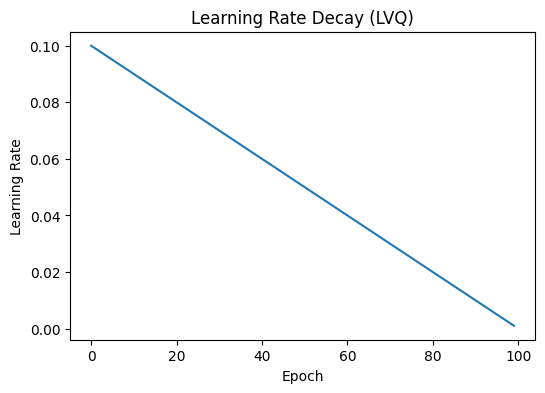

In [11]:
plt.figure(figsize=(6,4))
plt.plot(lr_list)
plt.title("Learning Rate Decay (LVQ)")
plt.xlabel("Epoch")
plt.ylabel("Learning Rate")
plt.show()

In [12]:
def lvq_predict(X, proto_0, proto_1):
    preds = []
    for x in X:
        d0 = euclidean_distance(x, proto_0)
        d1 = euclidean_distance(x, proto_1)
        preds.append(0 if d0 < d1 else 1)
    return np.array(preds)

In [13]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

knn_preds = knn.predict(X_test)
knn_acc = accuracy_score(y_test, knn_preds)

print("KNN Accuracy:", round(knn_acc * 100, 2), "%")

KNN Accuracy: 73.38 %


In [15]:
# Predict using LVQ
lvq_preds = lvq_predict(X_test, proto_0, proto_1)
lvq_acc = accuracy_score(y_test, lvq_preds)

comparison = pd.DataFrame({
    "Model": ["LVQ (From Scratch)", "KNN (sklearn)"],
    "Accuracy": [lvq_acc, knn_acc]
})

comparison

,Model,Accuracy
0,LVQ (From Scratch),0.727273
1,KNN (sklearn),0.733766


In [16]:
print("Final Prototype for Class 0 (Non-Diabetic):\n", proto_0)
print("\nFinal Prototype for Class 1 (Diabetic):\n", proto_1)

Final Prototype for Class 0 (Non-Diabetic):
 [0.15451641 0.36208128 0.4491563  0.20690582 0.1112     0.22446542
 0.1316578  0.10460143]

Final Prototype for Class 1 (Diabetic):
 [0.31609263 0.84207188 0.53145913 0.31571393 0.21009035 0.44555744
 0.23257038 0.24297318]
